# WP5 · 01 — Precipitation exposure twin (Build A′ vs Build B)

**Work package:** WP5 / MAUP–exposure sensitivity · plan `docs/maup_sensitivity_and_spatial_cv_plan.md` §3
**Owner:** Geospatial Lead · **Country:** Sri Lanka · **Variable:** precipitation only

## Why this notebook exists, and why it rebuilds Build A

WP5 asks a single question: **does the *construction* of the exposure variable move the exposure —
and later, the decision — independently of the weather itself?** The test is a twin pair of tables
built from *identical* climate fields that differ in one thing only: the weights used to collapse
grid cells into a district.

`wp5_00` already froze the weight field, and established that Build A and Build B differ **only** in
those weights. So this notebook is the weighted sum.

The complication: **the frozen Build A table is not on this machine.**
`rdhs_weekly_climate_exposure_2018_2025_v2_boundary_resolved.csv` (sha `3900082b…`, 10,842 rows) and
the ~9.8 GB ERA5/CHIRPS quarantine behind it were built 2026-06-12 under
`~/data_quarantine/geomatics/`, which does not exist here. `wp5_00`'s provenance records that sha,
but it was *transcribed from the build report*, not computed locally — the file has never been here.

Rebuilding both arms from one freshly-staged CHIRPS stack is therefore not a workaround, it is the
cleaner design: the two arms then share their inputs *by construction* rather than by assumption,
and any difference is attributable to the weights alone. We build **three** columns, not two:

| column | weights | what it is |
|---|---|---|
| `a_alltouched` | equal weight over every cell touching the polygon | **emulates the frozen Build A**, whose mask is `all_touched` |
| `a_frac` | fractional area (`w_area`) | the honest area-weighted arm — same pixel assignment as Build B |
| `b_pop` | population (`w_pop`) | **Build B** — the designated primary result |

`a_alltouched` earns its place by being the bridge: if the frozen table ever arrives, it is the
column to validate against, and it decomposes the A→B gap into a **mask** effect and a **weight**
effect rather than confounding the two.

**Temperature is not here.** ERA5-Land needs a free CDS key, which is not yet on this machine.
CHIRPS needs no account, so precipitation is the half that can be built today.

## Scope discipline

No outcome data is touched, no linkage to the dengue outcome, no models. This notebook produces an
exposure table and a contrast. Everything it writes is gitignored quarantine.

## 1 · Setup

Paths, seed, and the one convention that matters: everything is keyed to the **v2 boundary-resolved**
schema — ISO weeks, full 7-day spans, 417 weeks × 26 RDHS = 10,842 rows.

In [1]:
import json, hashlib, time
from pathlib import Path
from datetime import date, timedelta

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

SEED = 20260612                     # study-wide seed, same as wp5_00
np.random.seed(SEED)

REPO = Path.cwd().parent if Path.cwd().name == "notebooks_wp45" else Path.cwd()
GEOM = REPO.parent / "dengue_map_workpack" / "geometry" / "rdhs_26_v1.gpkg"
QUAR = REPO / "data_quarantine" / "wp5_exposure"      # gitignored; never commit exposure tables
CACHE = QUAR / "chirps_window"                        # staged SL window, npz per year
CACHE.mkdir(parents=True, exist_ok=True)

WEIGHTS = QUAR / "wp5_buildB_weights_chirps_p05_srilanka_2020.csv"

print("repo    ", REPO)
print("geometry", GEOM, "| exists:", GEOM.exists())
print("weights ", WEIGHTS.name, "| exists:", WEIGHTS.exists())
print("cache   ", CACHE)

repo     /Users/mpcr/aj/Dengue/srilanka-dengue-ews-calibration
geometry /Users/mpcr/aj/Dengue/dengue_map_workpack/geometry/rdhs_26_v1.gpkg | exists: True
weights  wp5_buildB_weights_chirps_p05_srilanka_2020.csv | exists: True
cache    /Users/mpcr/aj/Dengue/srilanka-dengue-ews-calibration/data_quarantine/wp5_exposure/chirps_window


## 2 · Geometry

26 RDHS units, EPSG:4326 — the same frozen frame every other notebook uses. The sha is checked
against `nb00_provenance.json` so a swapped geometry cannot pass silently.

In [2]:
gdf = gpd.read_file(GEOM)
sha16 = hashlib.sha256(GEOM.read_bytes()).hexdigest()[:16]

print("units      ", len(gdf))
print("crs        ", gdf.crs)
print("columns    ", list(gdf.columns))
print("sha256[:16]", sha16, "| expected 9e5e2c0a541ecac1 ->", sha16 == "9e5e2c0a541ecac1")
gdf[["geometry_id", "rdhs_name"]].head()

units       26
crs         EPSG:4326
columns     ['rdhs_id', 'rdhs_name', 'geometry_id', 'parent_district', 'province', 'build_rule', 'n_ds', 'geometry']
sha256[:16] 9e5e2c0a541ecac1 | expected 9e5e2c0a541ecac1 -> True


,geometry_id,rdhs_name
0,LK11,Colombo
1,LK12,Gampaha
2,LK13,Kalutara
3,LK21,Kandy
4,LK22,Matale


## 3 · The weight field, reused not rebuilt

`wp5_00` assigned every WorldPop 100 m pixel to a (district, CHIRPS cell) pair by its centre, then
summed population and cos(lat)-area per pair and normalised within district. That table is frozen;
this notebook only consumes it.

Both weight columns must sum to 1.0 within every district — if they don't, every downstream number
is scaled wrong in a way that looks plausible.

In [3]:
w = pd.read_csv(WEIGHTS)
print("rows          ", len(w))
print("districts     ", w.geometry_id.nunique())
print("columns       ", list(w.columns))

sums = w.groupby("geometry_id")[["w_area", "w_pop"]].sum()
print("\nweight sums per district: min/max")
print(sums.agg(["min", "max"]).round(9))
assert np.allclose(sums["w_area"], 1.0), "area weights do not normalise"
assert np.allclose(sums["w_pop"],  1.0), "population weights do not normalise"
print("\nboth weight sets normalise to 1.0 within every district")

rows           3044
districts      26
columns        ['unit', 'geometry_id', 'rdhs_name', 'cell_row', 'cell_col', 'pop_sum', 'area', 'w_area', 'w_pop']

weight sums per district: min/max
     w_area  w_pop
min     1.0    1.0
max     1.0    1.0

both weight sets normalise to 1.0 within every district


### 3.1 · How many cells actually carry the weight

Population weighting concentrates: a district's rainfall comes from far fewer cells once you weight
by where people are. The inverse Herfindahl (`1 / Σw²`) is the effective number of contributing cells.

In [4]:
eff = w.groupby("geometry_id").apply(
    lambda d: pd.Series({
        "n_cells":  len(d),
        "eff_area": 1.0 / np.sum(d.w_area ** 2),
        "eff_pop":  1.0 / np.sum(d.w_pop  ** 2),
    }),
    include_groups=False,
)
print(eff[["n_cells", "eff_area", "eff_pop"]].describe().round(1))
print("\nmedian effective cells — area %.1f, pop %.1f" % (eff.eff_area.median(), eff.eff_pop.median()))

       n_cells  eff_area  eff_pop
count     26.0      26.0     26.0
mean     117.1      93.0     41.3
std       57.6      51.6     28.8
min       39.0      27.4     10.9
25%       77.0      59.8     20.4
50%      101.5      76.0     36.2
75%      142.2     114.3     48.1
max      287.0     250.3    126.2

median effective cells — area 76.0, pop 36.2


## 4 · The CHIRPS grid — and the row-order trap

This is the step that silently ruins the build if it is assumed rather than asserted.

`wp5_00` stored `cell_row` / `cell_col` in **raster order**: row 0 at the *north* edge (+50°), so
`lat_centre = 50 − 0.05·(row + 0.5)`. The CHIRPS netCDF `latitude` axis runs the other way — it
**ascends from −50°**, so `lat_centre = −50 + 0.05·(i + 0.5)`.

The two are related by `i = 1999 − row`. Get it wrong and every district is handed rainfall from its
mirror latitude in the southern hemisphere — which produces a complete, plausible, entirely wrong
table. So: derive the coordinates both ways and assert they agree with the file's own axes.

In [5]:
RES, N_LAT = 0.05, 2000
EDGE_LAT_TOP, EDGE_LON_LEFT = 50.0, -180.0     # cell EDGES, per wp5_00 provenance (verified there)

def row_to_lat(row):  return EDGE_LAT_TOP  - RES * (np.asarray(row) + 0.5)   # raster order (north-down)
def col_to_lon(col):  return EDGE_LON_LEFT + RES * (np.asarray(col) + 0.5)
def row_to_nc(row):   return (N_LAT - 1) - np.asarray(row)                   # -> ascending-lat index

probe = w.iloc[1]
print("probe cell: %s  row=%d col=%d" % (probe.rdhs_name, probe.cell_row, probe.cell_col))
print("  lat (raster order) %.4f   lon %.4f" % (row_to_lat(probe.cell_row), col_to_lon(probe.cell_col)))
print("  netCDF lat index   %d" % row_to_nc(probe.cell_row))

r0, r1 = int(w.cell_row.min()), int(w.cell_row.max())
c0, c1 = int(w.cell_col.min()), int(w.cell_col.max())
print("\nweight-table extent: rows %d..%d  cols %d..%d" % (r0, r1, c0, c1))
print("  lat %.3f .. %.3f   lon %.3f .. %.3f"
      % (row_to_lat(r1), row_to_lat(r0), col_to_lon(c0), col_to_lon(c1)))

probe cell: Colombo  row=860 col=5197
  lat (raster order) 6.9750   lon 79.8750
  netCDF lat index   1139

weight-table extent: rows 803..881  cols 5193..5237
  lat 5.925 .. 9.825   lon 79.675 .. 81.875


### 4.1 · Assert the window against the file's own axes

Open one year remotely and read only the coordinate variables. The derived centres must match the
stored ones to floating-point tolerance. This is the check that makes the rest of the notebook safe.

In [6]:
import fsspec, h5netcdf

CHIRPS_URL = ("https://data.chc.ucsb.edu/products/CHIRPS-2.0/global_daily/"
              "netcdf/p05/chirps-v2.0.%d.days_p05.nc")

_f  = fsspec.open(CHIRPS_URL % 2019, block_size=2 ** 18).open()
_ds = h5netcdf.File(_f, "r")
nc_lat = _ds["latitude"][:]
nc_lon = _ds["longitude"][:]
print("file axes: lat", nc_lat.shape, "%.3f .. %.3f" % (nc_lat[0], nc_lat[-1]))
print("           lon", nc_lon.shape, "%.3f .. %.3f" % (nc_lon[0], nc_lon[-1]))
print("precip     ", _ds["precip"].shape, "chunks", _ds["precip"].chunks)

# the window, in netCDF (ascending-lat) index space
I0, I1 = int(row_to_nc(r1)), int(row_to_nc(r0))     # r1 is the southernmost row -> lowest nc index
J0, J1 = c0, c1
print("\nnetCDF window: lat idx %d..%d (%d)  lon idx %d..%d (%d)"
      % (I0, I1, I1 - I0 + 1, J0, J1, J1 - J0 + 1))

assert np.allclose(nc_lat[I0:I1 + 1], row_to_lat(np.arange(r1, r0 - 1, -1)), atol=1e-6), "lat mismatch"
assert np.allclose(nc_lon[J0:J1 + 1], col_to_lon(np.arange(c0, c1 + 1)),      atol=1e-6), "lon mismatch"
print("\nderived centres match the file's axes — row order and grid convention confirmed")

file axes: lat (2000,) -49.975 .. 49.975
           lon (7200,) -179.975 .. 179.975
precip      (365, 2000, 7200) chunks (20, 112, 400)

netCDF window: lat idx 1118..1196 (79)  lon idx 5193..5237 (45)

derived centres match the file's axes — row order and grid convention confirmed


## 5 · Stage the Sri Lanka window

The acquisition plan (§D) specifies per-day global GeoTIFFs, bbox-clipped on arrival — ~31 GB of
transfer for this window, and the 2026-06 build pulled ~9.8 GB that way.

That is no longer necessary. The yearly netCDFs are **netCDF-4/HDF5, chunked `(20, 112, 400)` with
gzip**, and Sri Lanka's bbox touches only 2×2 spatial chunks — so an HTTP range read pulls one whole
year of the window in roughly 25 seconds and never materialises the global grid at all.

Cached to quarantine as one `.npz` per year (~6 MB each), so this cell is a no-op on re-run.

In [7]:
YEARS = list(range(2018, 2026))

def stage_year(year):
    out = CACHE / ("chirps_p05_srilanka_%d.npz" % year)
    if out.exists():
        z = np.load(out)
        return z["precip"], z["dates"], 0.0
    t0 = time.time()
    f  = fsspec.open(CHIRPS_URL % year, block_size=2 ** 18).open()
    ds = h5netcdf.File(f, "r")
    arr = ds["precip"][:, I0:I1 + 1, J0:J1 + 1].astype("float32")
    t   = ds["time"][:]                              # days since 1980-01-01
    dates = np.array([(date(1980, 1, 1) + timedelta(days=int(d))).isoformat() for d in t])
    dt = time.time() - t0
    np.savez_compressed(out, precip=arr, dates=dates)
    return arr, dates, dt

stack, all_dates = [], []
for y in YEARS:
    arr, dts, dt = stage_year(y)
    stack.append(arr); all_dates.append(dts)
    print("%d  shape %-18s days %4d  %s" % (y, str(arr.shape), len(dts),
          ("%5.1fs" % dt) if dt else "cached"))

P = np.concatenate(stack, axis=0)
DATES = pd.to_datetime(np.concatenate(all_dates))
print("\nfull stack", P.shape, "dtype", P.dtype, "| %s .. %s" % (DATES[0].date(), DATES[-1].date()))

2018  shape (365, 79, 45)      days  365  cached
2019  shape (365, 79, 45)      days  365  cached
2020  shape (366, 79, 45)      days  366  cached
2021  shape (365, 79, 45)      days  365  cached
2022  shape (365, 79, 45)      days  365  cached
2023  shape (365, 79, 45)      days  365  cached
2024  shape (366, 79, 45)      days  366  cached
2025  shape (365, 79, 45)      days  365  cached

full stack (2922, 79, 45) dtype float32 | 2018-01-01 .. 2025-12-31


## 6 · Nodata

CHIRPS ships **no nodata tag** — `-9999` is ocean, and if it is not masked explicitly it enters the
weighted mean as 9.999 metres of rainfall. Mask first, look at the map second.

In [8]:
NODATA = -9990.0                                  # anything at/below is the -9999 sentinel
is_nd = P <= NODATA
print("cells total      ", P.size)
print("nodata cells     ", int(is_nd.sum()), "(%.1f%%)" % (100 * is_nd.mean()))
print("nodata is static ", bool((is_nd.all(axis=0) | (~is_nd).all(axis=0)).all()))

Pm = np.where(is_nd, np.nan, P)
land = ~is_nd[0]
print("land cells in window", int(land.sum()), "of", land.size)

v = Pm[~np.isnan(Pm)]
print("\nprecip mm/day: min %.2f  median %.2f  mean %.2f  max %.1f" % (v.min(), np.median(v), v.mean(), v.max()))
assert v.min() >= 0, "negative precipitation after masking"

cells total       10387710
nodata cells      3582372 (34.5%)
nodata is static  True
land cells in window 2329 of 3555

precip mm/day: min 0.00  median 0.00  mean 5.65  max 305.0


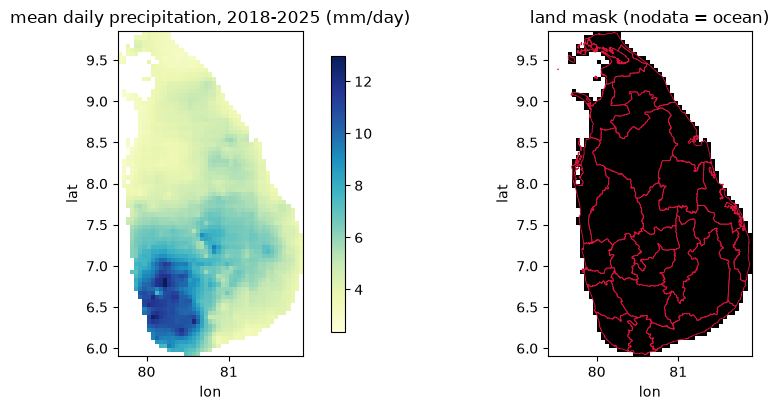

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
extent = [col_to_lon(J0) - RES / 2, col_to_lon(J1) + RES / 2,
          nc_lat[I0] - RES / 2,     nc_lat[I1] + RES / 2]

mean_map = np.full(land.shape, np.nan)          # ocean stays NaN; avoids an all-NaN nanmean
mean_map[land] = np.nanmean(Pm[:, land], axis=0)

m0 = ax[0].imshow(mean_map, origin="lower", extent=extent, cmap="YlGnBu")
ax[0].set_title("mean daily precipitation, 2018-2025 (mm/day)")
plt.colorbar(m0, ax=ax[0], shrink=0.85)

m1 = ax[1].imshow(land.astype(float), origin="lower", extent=extent, cmap="Greys")
ax[1].set_title("land mask (nodata = ocean)")
gdf.boundary.plot(ax=ax[1], color="crimson", linewidth=0.6)
for a in ax:
    a.set_xlabel("lon"); a.set_ylabel("lat")
plt.tight_layout(); plt.show()

## 7 · The ISO-week spine

Match the v2 boundary-resolved convention exactly: **417 ISO weeks, 2018–2025, every one a full
7-day span**, including the six that cross a year boundary (2019-W01 begins 2018-12-31; 2020-W53
runs into 2021). Nothing is a partial week — the v2 report's QC requires `n_chirps_days = 7` on
every row, and so does this build.

In [10]:
iso = DATES.isocalendar()
spine = pd.DataFrame({"date": DATES, "iso_year": iso.year.values, "iso_week": iso.week.values})
spine = spine[spine.iso_year.between(2018, 2025)]

wk = (spine.groupby(["iso_year", "iso_week"])
            .agg(n_days=("date", "size"), week_start=("date", "min"), week_end=("date", "max"))
            .reset_index())

print("weeks found        ", len(wk), "| expected 417 ->", len(wk) == 417)
print("weeks with 7 days  ", int((wk.n_days == 7).sum()))
print("per iso_year:\n", wk.groupby("iso_year").size().to_string())

assert (wk.n_days == 7).all(), "partial weeks present — v2 requires full 7-day spans"
print("\nboundary weeks (span crosses a year):")
print(wk[wk.week_start.dt.year != wk.week_end.dt.year].to_string(index=False))

weeks found         417 | expected 417 -> True
weeks with 7 days   417
per iso_year:
 iso_year
2018    52
2019    52
2020    53
2021    52
2022    52
2023    52
2024    52
2025    52

boundary weeks (span crosses a year):
 iso_year  iso_week  n_days week_start   week_end
     2019         1       7 2018-12-31 2019-01-06
     2020         1       7 2019-12-30 2020-01-05
     2020        53       7 2020-12-28 2021-01-03
     2021        52       7 2021-12-27 2022-01-02
     2022        52       7 2022-12-26 2023-01-01
     2025         1       7 2024-12-30 2025-01-05


## 8 · Weekly totals per grid cell

Sum the seven daily grids. Cell-level first, district-level second — collapsing in the other order
would bake the weights into a quantity that no longer sums to a rainfall total.

In [11]:
day_ix = {d: i for i, d in enumerate(DATES)}
wk = wk.sort_values(["iso_year", "iso_week"]).reset_index(drop=True)

W = np.empty((len(wk), P.shape[1], P.shape[2]), dtype="float32")
for k, row in wk.iterrows():
    ix = [day_ix[d] for d in pd.date_range(row.week_start, row.week_end)]
    assert len(ix) == 7
    W[k] = Pm[ix].sum(axis=0)

print("weekly cube", W.shape, "(weeks, lat, lon)")
wv = W[:, land]
print("weekly totals mm: min %.1f  median %.1f  mean %.1f  max %.1f"
      % (wv.min(), np.median(wv), wv.mean(), wv.max()))

weekly cube (417, 79, 45) (weeks, lat, lon)
weekly totals mm: min 0.0  median 21.2  mean 39.5  max 656.5


## 9 · The third mask — `all_touched`, to emulate the frozen Build A

The frozen build aggregated with per-RDHS cell masks over every cell the polygon touches, weighted
equally. `wp5_00` measured what that costs: roughly **31% of a district's weight lands in cells whose
centre of mass is somewhere else**. Reproducing it here is what lets the A→B gap be split into a mask
effect and a weight effect.

Ocean cells inside the touched set are dropped — otherwise a coastal district's mean is NaN.

In [12]:
from rasterio.features import rasterize
from rasterio.transform import from_origin

transform = from_origin(col_to_lon(J0) - RES / 2, row_to_lat(r0) + RES / 2, RES, RES)
H, Wd = P.shape[1], P.shape[2]

at_masks = {}
for _, row in gdf.iterrows():
    m = rasterize([(row.geometry, 1)], out_shape=(H, Wd), transform=transform,
                  all_touched=True, dtype="uint8").astype(bool)
    m = m[::-1]                                    # raster order -> ascending-lat order
    at_masks[row.geometry_id] = m & land           # drop ocean cells
    assert m.sum() > 0, "empty all_touched mask for %s" % row.rdhs_name

n_at = pd.Series({k: int(v.sum()) for k, v in at_masks.items()})
print("all_touched cells per district: min %d  median %d  max %d" % (n_at.min(), n_at.median(), n_at.max()))
print("districts with zero land cells:", int((n_at == 0).sum()))
assert (n_at > 0).all(), "a district has no valid land cell under all_touched"

all_touched cells per district: min 38  median 100  max 287
districts with zero land cells: 0


## 10 · Aggregate three ways

Same weekly cube, three collapses. Any difference between the columns is the construction, not the
weather — that is the entire WP5 argument, and it holds here *by construction* because the inputs
are literally the same array.

In [13]:
meta = (gdf[["geometry_id", "rdhs_name"]]
        .drop_duplicates()
        .set_index("geometry_id")["rdhs_name"].to_dict())

rows = []
for gid, grp in w.groupby("geometry_id"):
    i = row_to_nc(grp.cell_row.values).astype(int) - I0
    j = grp.cell_col.values.astype(int) - J0
    series = W[:, i, j]                                   # (weeks, cells)

    valid = ~np.isnan(series[0])                          # ocean cells inside the pair table
    wa = np.where(valid, grp.w_area.values, 0.0); wa = wa / wa.sum()
    wp = np.where(valid, grp.w_pop.values,  0.0)
    wp = wp / wp.sum() if wp.sum() > 0 else wa            # fallback if a district has no populated cell
    s  = np.nan_to_num(series)

    at = W[:, at_masks[gid]]

    rows.append(pd.DataFrame({
        "geometry_id": gid,
        "rdhs_name":   meta[gid],
        "iso_year":    wk.iso_year.values,
        "iso_week":    wk.iso_week.values,
        "week_start":  wk.week_start.dt.date.values,
        "week_end":    wk.week_end.dt.date.values,
        "precip_sum_mm_a_alltouched": np.nanmean(at, axis=1),
        "precip_sum_mm_a_frac":       s @ wa,
        "precip_sum_mm_b_pop":        s @ wp,
        "n_chirps_days": 7,
    }))

exp = pd.concat(rows, ignore_index=True).sort_values(
    ["iso_year", "iso_week", "geometry_id"]).reset_index(drop=True)

for c in ["a_alltouched", "a_frac", "b_pop"]:
    exp["precip_mean_daily_mm_" + c] = exp["precip_sum_mm_" + c] / 7.0

print("exposure table", exp.shape)
print("rows expected 417 x 26 =", 417 * 26, "->", len(exp) == 417 * 26)
exp.head()

exposure table (10842, 13)
rows expected 417 x 26 = 10842 -> True


,geometry_id,rdhs_name,iso_year,iso_week,week_start,week_end,precip_sum_mm_a_alltouched,precip_sum_mm_a_frac,precip_sum_mm_b_pop,n_chirps_days,precip_mean_daily_mm_a_alltouched,precip_mean_daily_mm_a_frac,precip_mean_daily_mm_b_pop
0,LK11,Colombo,2018,1,2018-01-01,2018-01-07,0.0,0.0,0.0,7,0.0,0.0,0.0
1,LK12,Gampaha,2018,1,2018-01-01,2018-01-07,0.0,0.0,0.0,7,0.0,0.0,0.0
2,LK13,Kalutara,2018,1,2018-01-01,2018-01-07,0.0,0.0,0.0,7,0.0,0.0,0.0
3,LK21,Kandy,2018,1,2018-01-01,2018-01-07,0.0,0.0,0.0,7,0.0,0.0,0.0
4,LK22,Matale,2018,1,2018-01-01,2018-01-07,0.0,0.0,0.0,7,0.0,0.0,0.0


## 11 · The contrast

Two gaps, reported separately:

- **mask effect** — `a_frac − a_alltouched`: same intent (area), different footprint.
- **weight effect** — `b_pop − a_frac`: same footprint, different weights. **This is Build A → Build B.**

In [14]:
exp["d_mask"]   = exp.precip_sum_mm_a_frac - exp.precip_sum_mm_a_alltouched
exp["d_weight"] = exp.precip_sum_mm_b_pop  - exp.precip_sum_mm_a_frac
exp["d_total"]  = exp.precip_sum_mm_b_pop  - exp.precip_sum_mm_a_alltouched

# NOTE on the percentage column: a per-row |d| / A' averages to a meaningless number here, because
# a dry district-week has A' near zero and the ratio explodes. The honest normaliser is the ratio of
# means — mean |displacement| against mean rainfall — which is what the tail table in 11.1 uses too.
def summarise(col, label):
    s = exp[col]
    return pd.Series({
        "mean_mm/wk": s.mean(), "median_mm/wk": s.median(),
        "sd_mm/wk": s.std(), "p05": s.quantile(.05), "p95": s.quantile(.95),
        "mean_abs": s.abs().mean(), "max_abs": s.abs().max(),
        "mean_abs_as_%_of_mean_A'": 100 * s.abs().mean() / exp.precip_sum_mm_a_frac.mean(),
    }, name=label)

print(pd.concat([summarise("d_mask", "mask (frac - all_touched)"),
                 summarise("d_weight", "weight (pop - frac)  <- A->B"),
                 summarise("d_total", "total (pop - all_touched)")], axis=1).round(3).to_string())

print("\ncorrelation between the two arms, over all 10,842 rows: %.6f"
      % exp.precip_sum_mm_a_frac.corr(exp.precip_sum_mm_b_pop))

                          mask (frac - all_touched)  weight (pop - frac)  <- A->B  total (pop - all_touched)
mean_mm/wk                                    0.087                        -0.748                     -0.660
median_mm/wk                                  0.000                        -0.129                     -0.194
sd_mm/wk                                      1.257                         5.716                      5.839
p05                                          -1.681                       -10.155                     -9.874
p95                                           2.072                         6.978                      7.527
mean_abs                                      0.763                         3.399                      3.539
max_abs                                      13.457                        72.586                     59.129
mean_abs_as_%_of_mean_A'                      1.776                         7.915                      8.241

correlation betwee

mean weekly displacement by district (mm/week):
              d_mask  d_weight  d_total
rdhs_name                              
Colombo        -0.59     -7.30    -7.89
Matara          0.88     -4.80    -3.92
Galle           0.70     -3.17    -2.47
Kegalle         0.26     -3.11    -2.86
Kandy          -0.18     -2.46    -2.64
Mannar          0.09     -2.45    -2.36
Kalutara        0.56     -2.09    -1.53
Batticaloa      0.01     -1.99    -1.98
Kalmunai        0.21     -1.81    -1.60
Vavuniya        0.10     -1.41    -1.31
Anuradhapura   -0.19     -0.95    -1.14
Gampaha         0.20     -0.93    -0.73
Badulla         0.09     -0.84    -0.75
Polonnaruwa    -0.00     -0.35    -0.36
Nuwara Eliya   -0.46     -0.30    -0.75
Matale          0.11     -0.29    -0.18
Trincomalee     0.16     -0.03     0.13
Killinochchi   -0.13      0.09    -0.05
Moneragala     -0.12      0.77     0.65
Mullaitivu      0.46      0.82     1.28
Ampara          0.31      0.93     1.24
Jaffna          0.21      1.06  

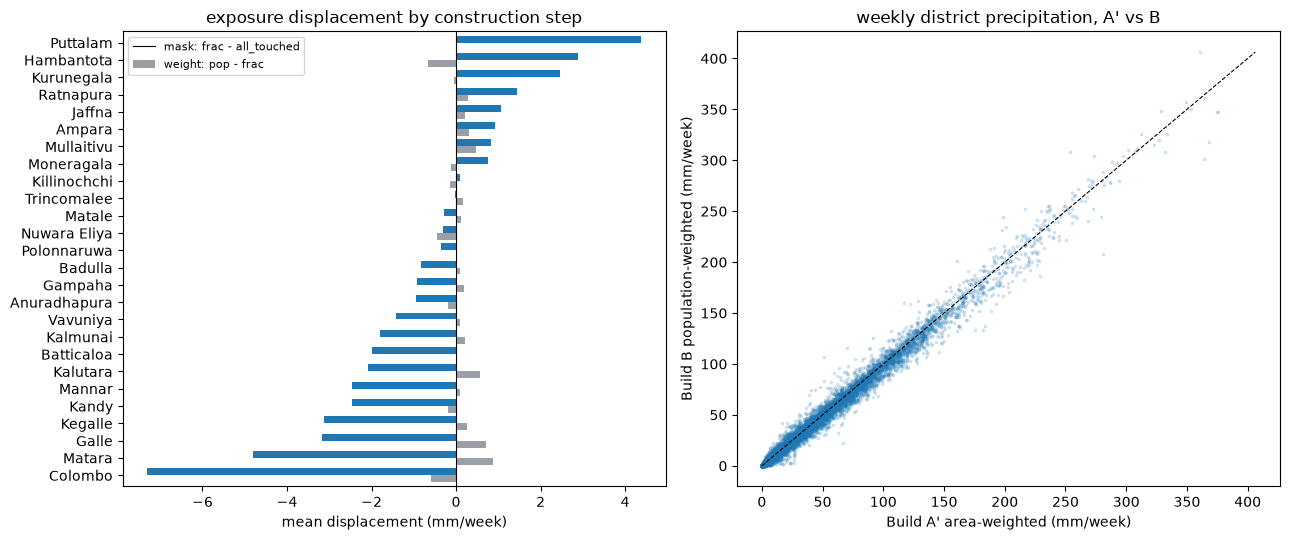

In [15]:
by_d = (exp.groupby("rdhs_name")[["d_mask", "d_weight", "d_total"]]
          .mean().sort_values("d_weight"))
print("mean weekly displacement by district (mm/week):")
print(by_d.round(2).to_string())

fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))
by_d[["d_mask", "d_weight"]].plot.barh(ax=ax[0], width=.8,
                                       color=["#9aa0a6", "#1f77b4"])
ax[0].axvline(0, color="k", lw=.8)
ax[0].set_xlabel("mean displacement (mm/week)"); ax[0].set_ylabel("")
ax[0].set_title("exposure displacement by construction step")
ax[0].legend(["mask: frac - all_touched", "weight: pop - frac"], fontsize=8)

ax[1].scatter(exp.precip_sum_mm_a_frac, exp.precip_sum_mm_b_pop, s=3, alpha=.15, color="#1f77b4")
lim = [0, exp[["precip_sum_mm_a_frac", "precip_sum_mm_b_pop"]].max().max()]
ax[1].plot(lim, lim, "k--", lw=.8)
ax[1].set_xlabel("Build A' area-weighted (mm/week)")
ax[1].set_ylabel("Build B population-weighted (mm/week)")
ax[1].set_title("weekly district precipitation, A' vs B")
plt.tight_layout(); plt.show()

### 11.1 · Where it matters — the wet tail

A mean displacement near zero is not the same as no effect. Alerts fire on *high* weeks, so the
quantity that matters for a decision analysis is the displacement in the upper tail of rainfall.

In [16]:
q = exp.precip_sum_mm_a_frac.quantile([.5, .9, .95, .99])
bands = [("all weeks", exp),
         ("p50+", exp[exp.precip_sum_mm_a_frac >= q[.5]]),
         ("p90+", exp[exp.precip_sum_mm_a_frac >= q[.9]]),
         ("p95+", exp[exp.precip_sum_mm_a_frac >= q[.95]]),
         ("p99+", exp[exp.precip_sum_mm_a_frac >= q[.99]])]

print(pd.DataFrame([{
    "band": name, "n": len(d),
    "mean A' mm/wk": d.precip_sum_mm_a_frac.mean(),
    "mean |d_weight| mm/wk": d.d_weight.abs().mean(),
    "as % of A'": 100 * d.d_weight.abs().mean() / d.precip_sum_mm_a_frac.mean(),
    "max |d_weight|": d.d_weight.abs().max(),
} for name, d in bands]).round(2).to_string(index=False))

     band     n  mean A' mm/wk  mean |d_weight| mm/wk  as % of A'  max |d_weight|
all weeks 10842          42.94                   3.40        7.91           72.59
     p50+  5421          77.89                   5.33        6.84           72.59
     p90+  1085         158.63                   8.56        5.40           72.59
     p95+   543         191.75                  10.30        5.37           72.59
     p99+   109         262.98                  12.89        4.90           72.59


## 12 · QC

The v2 report's checks, applied to this table. Anything that fails here invalidates the build.

In [17]:
checks = {
    "rows = 417 x 26":            len(exp) == 10842,
    "26 districts":               exp.geometry_id.nunique() == 26,
    "417 ISO weeks":              exp.groupby(["iso_year", "iso_week"]).ngroups == 417,
    "iso_year 2018-2025":         exp.iso_year.between(2018, 2025).all(),
    "no duplicate keys":          not exp.duplicated(["iso_year", "iso_week", "geometry_id"]).any(),
    "no nulls":                   not exp.isna().any().any(),
    "n_chirps_days = 7 all rows": (exp.n_chirps_days == 7).all(),
    "precip >= 0 (all arms)":     bool((exp[[c for c in exp if c.startswith("precip_")]] >= 0).all().all()),
    "Kalmunai present":           "Kalmunai" in set(exp.rdhs_name),
}
for k, v in checks.items():
    print("%-30s %s" % (k, "PASS" if v else "FAIL"))
assert all(checks.values()), "QC failed"

rows = 417 x 26                PASS
26 districts                   PASS
417 ISO weeks                  PASS
iso_year 2018-2025             PASS
no duplicate keys              PASS
no nulls                       PASS
n_chirps_days = 7 all rows     PASS
precip >= 0 (all arms)         PASS
Kalmunai present               PASS


## 13 · Write the table and its provenance

Quarantined and gitignored — exposure tables are never committed.

In [18]:
OUT = QUAR / "wp5_precip_exposure_twin_srilanka_v1.csv"
exp.to_csv(OUT, index=False)
sha = hashlib.sha256(OUT.read_bytes()).hexdigest()

prov = {
    "notebook": "wp5_01_precipitation_exposure_twin",
    "workpackage": "WP5 / MAUP exposure sensitivity (plan section 3)",
    "country": "sri_lanka", "seed": SEED,
    "variable": "precipitation only — ERA5-Land temperature awaits a CDS key",
    "source": {
        "product": "CHIRPS v2.0 daily p05 (global_daily/netcdf/p05)",
        "access": "HTTP range read of netCDF-4 chunks; no account required",
        "years": YEARS, "window_rows_nc": [I0, I1], "window_cols": [J0, J1],
        "nodata_masked": -9999,
    },
    "weights": {"file": WEIGHTS.name, "from_notebook": "wp5_00_population_weight_field"},
    "geometry_sha256_16": sha16,
    "arms": {
        "a_alltouched": "equal weight over all_touched cells — emulates frozen Build A",
        "a_frac": "fractional-area weights (w_area)",
        "b_pop": "population weights (w_pop) — Build B",
    },
    "build_a_reference": {
        "file": "rdhs_weekly_climate_exposure_2018_2025_v2_boundary_resolved.csv",
        "sha256_16": "3900082bcda70e87",
        "status": "NOT PRESENT ON THIS MACHINE — sha transcribed from build report, never verified locally",
        "consequence": "both arms rebuilt from one staged stack; a_alltouched is the validation bridge",
    },
    "rows": int(len(exp)), "iso_weeks": 417,
    "displacement_mm_per_week": {
        "mask_mean":   float(exp.d_mask.mean()),
        "weight_mean": float(exp.d_weight.mean()),
        "weight_mean_abs": float(exp.d_weight.abs().mean()),
        "weight_max_abs":  float(exp.d_weight.abs().max()),
    },
    "output_sha256_16": sha[:16],
}
(QUAR / "wp5_01_provenance.json").write_text(json.dumps(prov, indent=2))

print("wrote", OUT.name, "| %d rows | sha256[:16] %s" % (len(exp), sha[:16]))
print("wrote wp5_01_provenance.json")

wrote wp5_precip_exposure_twin_srilanka_v1.csv | 10842 rows | sha256[:16] fe46af09328ccaba
wrote wp5_01_provenance.json


## 14 · Recap

Every number this notebook stands on, in one place.

In [19]:
recap = pd.DataFrame([
    ("staged", "CHIRPS years", "%d (%d-%d)" % (len(YEARS), YEARS[0], YEARS[-1])),
    ("staged", "daily grids", "%d days x %d x %d cells" % P.shape),
    ("staged", "transfer avoided vs plan section D", "~31 GB of daily GeoTIFFs -> chunk range reads"),
    ("grid",   "land cells in window", "%d of %d" % (land.sum(), land.size)),
    ("weights","cell-district pairs", "%d" % len(w)),
    ("weights","effective cells (median) area / pop", "%.1f / %.1f" % (eff.eff_area.median(), eff.eff_pop.median())),
    ("table",  "rows", "%d (417 ISO weeks x 26 RDHS)" % len(exp)),
    ("table",  "mean weekly precip, A' area-weighted", "%.1f mm" % exp.precip_sum_mm_a_frac.mean()),
    ("table",  "mean weekly precip, B population-weighted", "%.1f mm" % exp.precip_sum_mm_b_pop.mean()),
    ("result", "mask effect (frac - all_touched), mean", "%+.2f mm/wk" % exp.d_mask.mean()),
    ("result", "weight effect A->B, mean", "%+.2f mm/wk" % exp.d_weight.mean()),
    ("result", "weight effect A->B, mean |.|", "%.2f mm/wk" % exp.d_weight.abs().mean()),
    ("result", "weight effect A->B, max |.|", "%.1f mm/wk" % exp.d_weight.abs().max()),
    ("result", "A' vs B correlation", "%.6f" % exp.precip_sum_mm_a_frac.corr(exp.precip_sum_mm_b_pop)),
    ("open",   "temperature arm", "blocked — ERA5-Land needs a free CDS key"),
    ("open",   "frozen Build A", "absent from this machine; a_alltouched is the bridge"),
    ("open",   "decision impact", "blocked — needs the model, not just the exposure"),
], columns=["stage", "quantity", "value"])
recap

,stage,quantity,value
0,staged,CHIRPS years,8 (2018-2025)
1,staged,daily grids,2922 days x 79 x 45 cells
2,staged,transfer avoided vs plan section D,~31 GB of daily GeoTIFFs -> chunk range reads
3,grid,land cells in window,2329 of 3555
4,weights,cell-district pairs,3044
5,weights,effective cells (median) area / pop,76.0 / 36.2
6,table,rows,10842 (417 ISO weeks x 26 RDHS)
7,table,"mean weekly precip, A' area-weighted",42.9 mm
8,table,"mean weekly precip, B population-weighted",42.2 mm
9,result,"mask effect (frac - all_touched), mean",+0.09 mm/wk


## What this establishes, and what it does not

**Establishes.** A population-weighted precipitation exposure table for Sri Lanka, 2018–2025, on the
v2 schema, built from the same daily grids as its area-weighted twin — so the difference between them
is the construction and nothing else. The displacement is reported both on average and in the wet
tail, where alerts actually fire.

**Does not establish.** Whether that displacement *changes a decision*. That is the second half of
WP5 and it needs the fitted model, which the repo does not hold — it carries predictions, not a
design matrix, the same blocker as `instruction_m6.md` §8. Nor does it say anything about
temperature, where `wp5_00` predicted the larger effect (−1.75 °C to +0.83 °C): that arm needs
ERA5-Land and therefore a CDS key.

**One caveat worth carrying.** The weight field is WorldPop 2020 held constant across a 2018–2025
window (`wp5_00` §11 measured the drift at ~1.1% of a typical weight), and ~1.4% of the population
falls outside the 26 polygons on the coastline. Both are bounded and reported, not hidden.